# Youth Labour Force Participation Rate vs Unemployment

Aligned with the project proposal **"Forecasting Underemployment in Sri Lanka Using Machine Learning"**, this combination explores **Youth LFPR**, which is hypothesized to be the top-ranked predictor variables.

Here we are charting the **Labor force participation rate for ages 15-24 (%)** against our extensive World Bank unemployment base dataset spanning more than 30 years (n > 30).

## 1. Data Loading

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr

# 1. Load Long-term Unemployment Base (World Bank)
unemp_df = pd.read_csv('../economy/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv', skiprows=4)
unemp_sri_lanka = unemp_df[unemp_df['Country Name'] == 'Sri Lanka'].copy()
years = [str(y) for y in range(1990, 2024)]
unemp_long = unemp_sri_lanka[['Country Name'] + years].melt(
    id_vars=['Country Name'], var_name='Year', value_name='Unemployment_Rate'
)
unemp_long['Year'] = unemp_long['Year'].astype(int)
unemp_long = unemp_long.dropna().set_index('Year')

# 2. Load Youth LFPR Data (Ages 15-24)
youth_lfpr_df = pd.read_csv(
    "../labour/finalized_csv/Labor_force_participation_rate,_total_(% of total population ages 15-64)_(modeled ILO estimate)_sl_indicators/Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate).csv"
)
youth_lfpr_df.set_index("Year", inplace=True)
youth_lfpr_df.sort_index(inplace=True)

# 3. Merge Long-term Series
merged_df = unemp_long[['Unemployment_Rate']].join(youth_lfpr_df[['Value']].rename(columns={'Value': 'youth_lfpr'}), how='inner').reset_index()
merged_df.head(5)

,Year,Unemployment_Rate,youth_lfpr
0,1991,14.661,50.198
1,1992,14.220,47.966
2,1993,13.820,47.257
3,1994,13.030,49.932
4,1995,12.270,43.172


## 2. Correlation Statistics

In [5]:
unemp_vals = merged_df['Unemployment_Rate'].values
youth_vals = merged_df['youth_lfpr'].values

pearson_corr, pearson_pv = pearsonr(youth_vals, unemp_vals)
spearman_corr, spearman_pv = spearmanr(youth_vals, unemp_vals)

print("================== Extrapolated Hypothesis Testing Output ==================")
print(f"Years covered:         {int(merged_df['Year'].min())} to {int(merged_df['Year'].max())}")
print(f"Number of Obs (n):     {len(merged_df)}")
print(f"Pearson Correlation:   {pearson_corr:>7.4f} (p-value: {pearson_pv:.5f})")
print(f"Spearman Correlation:  {spearman_corr:>7.4f} (p-value: {spearman_pv:.5f})")
print("============================================================================")

================== Extrapolated Hypothesis Testing Output ==================
Years covered:         1991 to 2023
Number of Obs (n):     33
Pearson Correlation:    0.8733 (p-value: 0.00000)
Spearman Correlation:   0.8632 (p-value: 0.00000)


## 3. Visualization

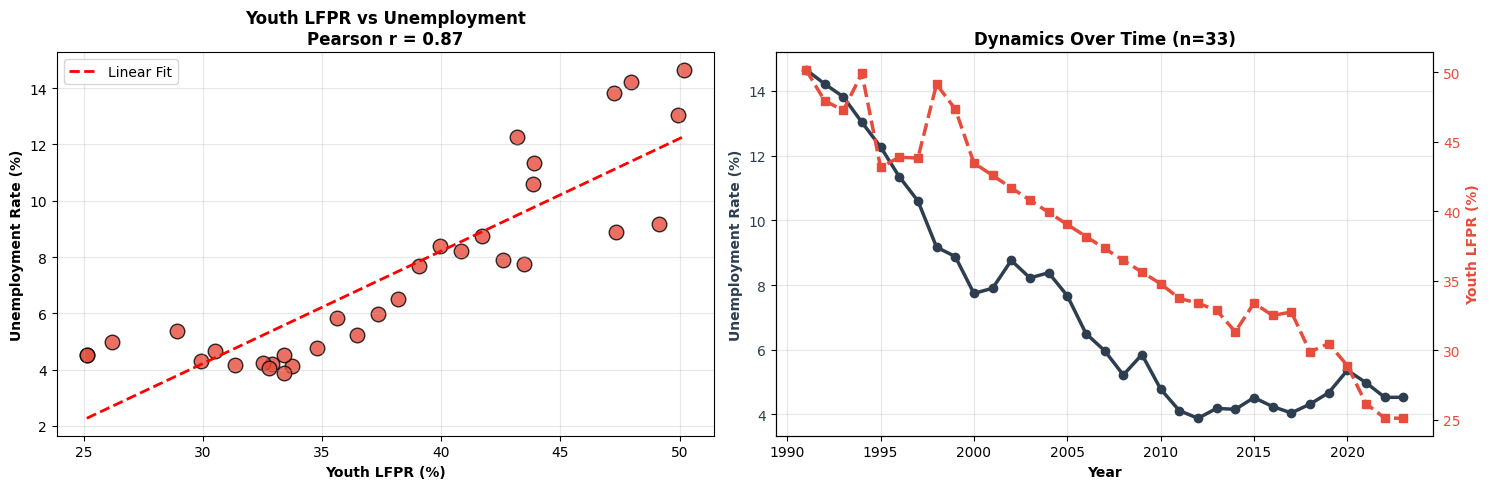

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scatter
ax1.scatter(youth_vals, unemp_vals, alpha=0.8, s=110, color='#e74c3c', edgecolors='black')
z = np.polyfit(youth_vals, unemp_vals, 1)
p = np.poly1d(z)
y_sorted = np.sort(youth_vals)
ax1.plot(y_sorted, p(y_sorted), "r--", linewidth=2, label='Linear Fit')
ax1.set_xlabel('Youth LFPR (%)', fontweight='bold')
ax1.set_ylabel('Unemployment Rate (%)', fontweight='bold')
ax1.set_title(f'Youth LFPR vs Unemployment\nPearson r = {pearson_corr:.2f}', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Dynamics
color_u = '#2c3e50'
color_y = '#e74c3c'
ax2.plot(merged_df['Year'], unemp_vals, marker='o', linewidth=2.5, color=color_u)
ax2.set_xlabel('Year', fontweight='bold')
ax2.set_ylabel('Unemployment Rate (%)', color=color_u, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_u)

ax2_twin = ax2.twinx()
ax2_twin.plot(merged_df['Year'], youth_vals, marker='s', linewidth=2.5, color=color_y, linestyle='--')
ax2_twin.set_ylabel('Youth LFPR (%)', color=color_y, fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor=color_y)
ax2.set_title(f'Dynamics Over Time (n={len(merged_df)})', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()